# Analsis y procesamiento de señales

## Trabajo Practico N^0

### Bernardita Aragon

En este trabajo se implementará una función generadora de señales senoidales, permitiendo modificar parámetros como la amplitud, el valor medio, la frecuencia, la fase, la cantidad de muestras y la frecuencia de muestreo. Luego se analizará el comportamiento de la señal para distintas frecuencias propuestas en la consigna.

In [3]:
#importacion de modulo
import numpy as np
import matplotlib.pyplot as plt 

A continuación se definen la frecuencia de muestreo, la cantidad de muestras y el tiempo entre cada muestra que se utilizarán para generar las señales.

In [4]:
fs=1000 #Hz frecuencia fija
N=1000 #muestras
ts= 1/ fs #espaciado entre muestras

A continuación se define la función `mi_funcion_sen`, encargada de generar la señal senoidal a partir de los parámetros de amplitud, valor medio, frecuencia, fase, cantidad de muestras y frecuencia de muestreo.

In [5]:
def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs): #si no me pasas los valores usa esos que le estoy dando    
    
    ts= 1/ fs #tiempo entre cada muestra
    tt= np.arange(0,nn) *ts #tiempo de cada muestra
    xx= dc + vmax*np.sin(2 * np.pi * ff * tt + ph)

    return(tt, xx)

Como primera prueba se genera una señal senoidal de 1 Hz, utilizando una amplitud de 1.5 V, valor medio igual a 0 V y fase inicial igual a 0.

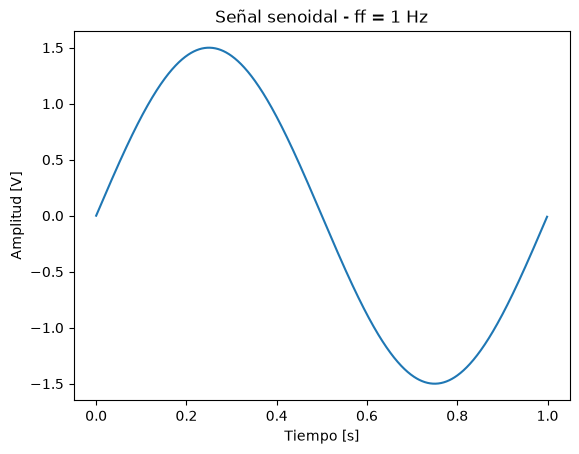

In [6]:
vmax = 1.5 #amplitud
dc=0 #desplazamiento
ff = 1 #frecuencia varaible
ph = 0
nn=N

tt= np.arange(0,nn) *ts #se mide en segundos
xx= dc + vmax*np.sin(2 * np.pi * ff * tt + ph)
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 1, ph=0, nn = N, fs = fs)


plt.plot(tt, xx) #plotear estos dos pares ordenados
plt.title("Señal senoidal - ff = 1 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

En este caso, al utilizar una frecuencia de 1 Hz, se observa un ciclo completo de la señal senoidal en un segundo. La amplitud máxima es de 1.5 V y el valor medio es 0 V.

A continuación se analiza la señal para una frecuencia de 500 Hz, manteniendo la frecuencia de muestreo y la cantidad muestras.

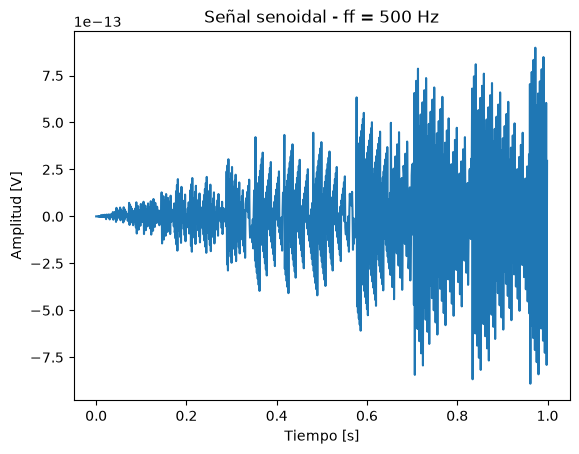

In [7]:
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 500, ph=0, nn = N, fs = fs)
plt.plot(tt, xx) 
plt.title("Señal senoidal - ff = 500 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

Como la frecuencia de muestreo es fs = 1000 Hz, una frecuencia de 500 Hz coincide con la frecuencia de Nyquist, fs/2. Con fase inicial igual a 0, las muestras de la señal senoidal deberían ser iguales a 0. Los pequeños valores que pueden observarse en el gráfico se deben a errores numéricos de cálculo.

Ahora se analiza la señal para una frecuencia de 999 Hz.

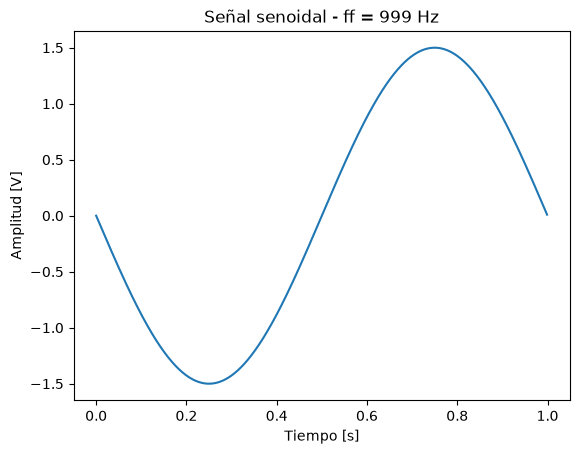

In [8]:
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 999, ph=0, nn = N, fs = fs)
plt.plot(tt, xx) 
plt.title("Señal senoidal - ff = 999 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

Como 999 Hz supera la frecuencia de Nyquist de 500 Hz, la señal no puede representarse correctamente con una frecuencia de muestreo de 1000 Hz y aparece aliasing. Las muestras obtenidas se comportan como una señal aparente de 1 Hz, pero invertida respecto de la señal original de 1 Hz.

Se analiza la señal para una frecuencia de 1001 Hz.

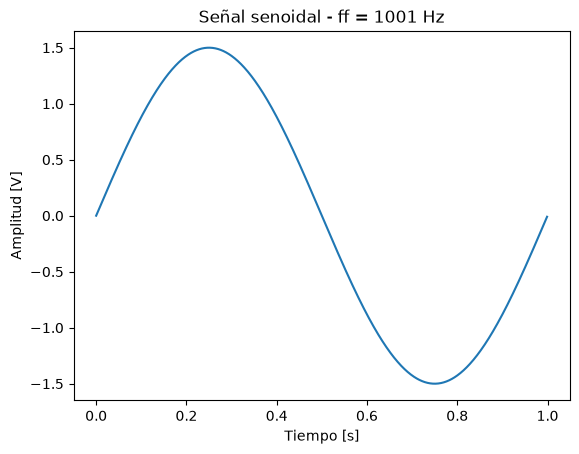

In [9]:
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 1001, ph=0, nn = N, fs = fs)
plt.plot(tt, xx) 
plt.title("Señal senoidal - ff = 1001 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

Al utilizar una frecuencia de 1001 Hz con una frecuencia de muestreo de 1000 Hz, las muestras obtenidas no representan directamente una señal de 1001 Hz. En el gráfico se observa una señal aparente de 1 Hz.

Finalmente se analiza la señal para una frecuencia de 2001 Hz.

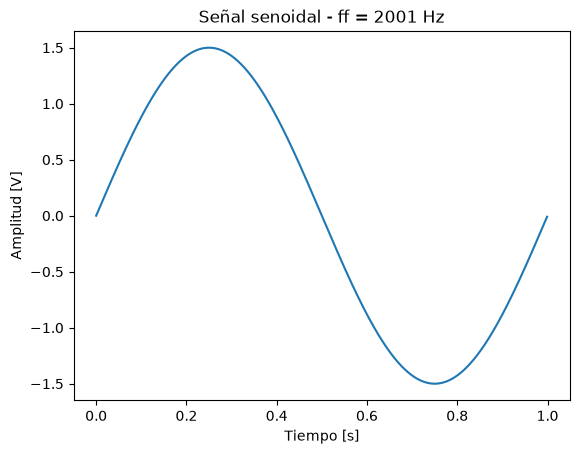

In [10]:
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 2001, ph=0, nn = N, fs = fs)
plt.plot(tt, xx) 
plt.title("Señal senoidal - ff = 2001 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

Al utilizar una frecuencia de 2001 Hz con una frecuencia de muestreo de 1000 Hz, las muestras obtenidas vuelven a mostrar una señal aparente de 1 Hz. Esto ocurre porque 2001 Hz difiere de un múltiplo de la frecuencia de muestreo en 1 Hz.

## Conclusión

Para concluir, para representar correctamente una señal la frecuencia de muestreo debe ser mayor al doble de la frecuencia de la señal. En nuestro caso, como `fs = 1000 Hz`, el límite de Nyquist es de `500 Hz`.

Para `ff = 1 Hz` la señal se representa correctamente. En `ff = 500 Hz` estamos justo en el límite y, con la fase utilizada, las muestras no permiten ver correctamente la senoide. En cambio, para `999 Hz`, `1001 Hz` y `2001 Hz` se supera el límite de Nyquist, por lo que aparecen señales aparentes de menor frecuencia. Con estas pruebas se pudo observar cómo la frecuencia de muestreo influye en la representación de una señal.